In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
import random

In [2]:
class SevenClassDataset:
    def __init__(self, data_path):
        self.data_path = Path(data_path)
        self.classes = ['20_speed_limit', '60_speed_limit', 'bike_lane', 
                       'children_crossing', 'do_not_enter', 
                       'pedestrian_crossing', 'stop']
        self.num_classes = len(self.classes)
        
        # GTSRB mapping
        self.gtsrb_class_mapping = {
            '20_speed_limit': 0,    # GTSRB class 0: Speed limit 20
            '60_speed_limit': 3,    # GTSRB class 3: Speed limit 60  
            'bike_lane': 29,        # GTSRB class 29: Bicycles crossing
            'children_crossing': 28, # GTSRB class 28: Children crossing
            'do_not_enter': 17,     # GTSRB class 17: No entry
            'pedestrian_crossing': 27, # GTSRB class 27: Pedestrians
            'stop': 14              # GTSRB class 14: Stop
        }
        
        # Reverse mapping for training
        self.gtsrb_to_7class = {
            0: 0,   # 20_speed_limit
            3: 1,   # 60_speed_limit  
            29: 2,  # bike_lane
            28: 3,  # children_crossing
            17: 4,  # do_not_enter
            27: 5,  # pedestrian_crossing
            14: 6   # stop
        }
        
    def load_dataset(self):
        splits = ['Train', 'Test', 'Val']
        images = {'train': [], 'test': [], 'val': []}
        labels = {'train': [], 'test': [], 'val': []}
        
        for split in splits:
            split_path = self.data_path / split
            if split_path.exists():
                for class_name in self.classes:
                    class_path = split_path / class_name
                    if class_path.exists():
                        for img_file in class_path.glob('*.*'):
                            img = cv2.imread(str(img_file))
                            if img is not None:
                                img = cv2.resize(img, (64, 64))
                                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                                split_key = split.lower()
                                images[split_key].append(img)
                                # Use GTSRB mapping for transfer learning
                                gtsrb_label = self.gtsrb_class_mapping[class_name]
                                labels[split_key].append(gtsrb_label)
        
        for split in images:
            if images[split]:
                images[split] = np.array(images[split])
                labels[split] = np.array(labels[split])
            
        return images, labels

dataset = SevenClassDataset('datazerodce')
images, labels = dataset.load_dataset()

print(f"Dataset sizes:")
print(f"Training: {len(images['train'])} images")
print(f"Validation: {len(images['val'])} images")
print(f"Test: {len(images['test'])} images")

Dataset sizes:
Training: 4616 images
Validation: 1456 images
Test: 1456 images


In [3]:
class DataPreprocessor:
    def __init__(self, target_size=(64, 64)):
        self.target_size = target_size
    
    def augment_image(self, image):
        image = cv2.resize(image, self.target_size)
        
        aug_type = random.choice(['rotate', 'zoom', 'brightness', 
                                  'gaussian_noise', 'none'])
        
        if aug_type == 'rotate':
            angle = random.uniform(-15, 15)
            matrix = cv2.getRotationMatrix2D(
                (self.target_size[0]//2, self.target_size[1]//2), angle, 1.0
            )
            result = cv2.warpAffine(image, matrix, self.target_size)
            
        elif aug_type == 'zoom':
            zoom_factor = random.uniform(0.8, 1.2)
            new_size = int(self.target_size[0] * zoom_factor)
            resized = cv2.resize(image, (new_size, new_size))
            if zoom_factor > 1:
                start = (new_size - self.target_size[0]) // 2
                cropped = resized[start:start+self.target_size[0], start:start+self.target_size[1]]
                result = cv2.resize(cropped, self.target_size)
            else:
                pad = (self.target_size[0] - new_size) // 2
                padded = cv2.copyMakeBorder(resized, pad, pad, pad, pad, cv2.BORDER_REFLECT)
                result = cv2.resize(padded, self.target_size)
                
        elif aug_type == 'brightness':
            hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
            hsv = hsv.astype(np.float32)
            hsv[:,:,2] *= random.uniform(0.7, 1.3)
            hsv[:,:,2] = np.clip(hsv[:,:,2], 0, 255)
            hsv = hsv.astype(np.uint8)
            result = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
            
        elif aug_type == 'gaussian_noise':
            noise = np.random.normal(0, 25, image.shape).astype(np.int16)
            noisy_image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
            result = noisy_image
        
        else:
            result = image
        
        return cv2.resize(result, self.target_size)

    def augment_training_data(self, images, labels, augmentation_factor=1):
        augmented_images = []
        augmented_labels = []
        
        
        for img, label in zip(images, labels):
            img_resized = cv2.resize(img, self.target_size)
            augmented_images.append(img_resized)
            augmented_labels.append(label)
            
            for _ in range(augmentation_factor):
                aug_img = self.augment_image(img)
                aug_img_resized = cv2.resize(aug_img, self.target_size)
                augmented_images.append(aug_img_resized)
                augmented_labels.append(label)
        
        augmented_images = np.stack(augmented_images, axis=0)
        augmented_labels = np.array(augmented_labels)
        
        print(f"Training set after augmentation: {len(augmented_images)} images")
        print(f"Final image shape: {augmented_images[0].shape}")
        return augmented_images, augmented_labels

In [4]:
preprocessor = DataPreprocessor()

X_train_aug, y_train_aug_gtsrb = preprocessor.augment_training_data(
    images['train'], labels['train'], augmentation_factor=1
)

X_val_orig = images['val']
X_test_orig = images['test']
y_val_orig_gtsrb = labels['val']
y_test_orig_gtsrb = labels['test']

print(f"\nFinal dataset sizes (1:1 augmentation):")
print(f"Training set: {len(X_train_aug)} images")
print(f"Validation set: {len(X_val_orig)} images")
print(f"Test set: {len(X_test_orig)} images")

Training set after augmentation: 9232 images
Final image shape: (64, 64, 3)

Final dataset sizes (1:1 augmentation):
Training set: 9232 images
Validation set: 1456 images
Test set: 1456 images


In [5]:
def map_gtsrb_to_7class(labels_gtsrb, mapping_dict):
    return np.array([mapping_dict[label] for label in labels_gtsrb])

y_train_aug = map_gtsrb_to_7class(y_train_aug_gtsrb, dataset.gtsrb_to_7class)
y_val_orig = map_gtsrb_to_7class(y_val_orig_gtsrb, dataset.gtsrb_to_7class)
y_test_orig = map_gtsrb_to_7class(y_test_orig_gtsrb, dataset.gtsrb_to_7class)

print(f"\nLabel mapping examples:")
print(f"GTSRB labels: {y_train_aug_gtsrb[:10]}")
print(f"7-class labels: {y_train_aug[:10]}")


Label mapping examples:
GTSRB labels: [0 0 0 0 0 0 0 0 0 0]
7-class labels: [0 0 0 0 0 0 0 0 0 0]


In [7]:
def create_64x64_model_with_phase1_weights(phase1_model_path):
    # Create base ResNet50 for 64x64 input
    base_model = tf.keras.applications.ResNet50(
        weights=None,
        include_top=False,
        input_shape=(64, 64, 3) 
    )
    
    inputs = tf.keras.Input(shape=(64, 64, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(43, activation='softmax', name='output_43class')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    # Load your Phase 1 weights
    print("Loading Phase 1 weights into 64x64 model...")
    original_model = tf.keras.models.load_model(phase1_model_path)
    
    # Load weights layer by layer
    weights_loaded = 0
    for target_layer in model.layers:
        for source_layer in original_model.layers:
            if target_layer.name == source_layer.name:
                try:
                    target_layer.set_weights(source_layer.get_weights())
                    print(f"✓ Loaded weights for {target_layer.name}")
                    weights_loaded += 1
                    break
                except Exception as e:
                    print(f"⚠ Skipped {target_layer.name}: {e}")
    
    print(f"Successfully loaded weights for {weights_loaded} layers")
    return model, base_model

resnet_model, base_model = create_64x64_model_with_phase1_weights('gtsrb_model_phase1final_continued.h5')

Loading Phase 1 weights into 64x64 model...
✓ Loaded weights for input_2
✓ Loaded weights for resnet50
✓ Loaded weights for global_average_pooling2d
✓ Loaded weights for dense
✓ Loaded weights for batch_normalization
✓ Loaded weights for dropout
✓ Loaded weights for dense_1
Successfully loaded weights for 7 layers


In [8]:
#preprocess same as phase 1
def preprocess_input_resnet(x):
    x = x.astype('float32')
    x = tf.keras.applications.resnet50.preprocess_input(x)
    return x

X_train_preprocessed = preprocess_input_resnet(X_train_aug)
X_val_preprocessed = preprocess_input_resnet(X_val_orig)
X_test_preprocessed = preprocess_input_resnet(X_test_orig)

#  use 7 classes for categorical conversion
y_train_categorical = keras.utils.to_categorical(y_train_aug, 7)
y_val_categorical = keras.utils.to_categorical(y_val_orig, 7)
y_test_categorical = keras.utils.to_categorical(y_test_orig, 7)

In [9]:
#calculate class weights
class_weights_aug = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug),
    y=y_train_aug
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_aug)}

print("\nClass weights (after augmentation):")
for class_idx, weight in class_weight_dict.items():
    print(f"Class {dataset.classes[class_idx]}: {weight:.4f}")


Class weights (after augmentation):
Class 20_speed_limit: 3.1401
Class 60_speed_limit: 0.4677
Class bike_lane: 2.4423
Class children_crossing: 1.0793
Class do_not_enter: 0.6022
Class pedestrian_crossing: 2.7476
Class stop: 0.8454


In [ ]:
from tensorflow.keras import Model, layers, optimizers

# Remove old (43-class) output layer
x = resnet_model.layers[-2].output  # get output of dense_1 (256 units)
new_output = layers.Dense(7, activation='softmax', name='new_output')(x)

fine_tuned_model = Model(inputs=resnet_model.input, outputs=new_output)

# Freeze earlier layers first
for layer in fine_tuned_model.layers[:-30]:  # freeze all except last ~30 layers
    layer.trainable = False

# Compile
fine_tuned_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tuned_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 resnet50 (Functional)       (None, 2, 2, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0   

In [41]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_7class_model_zerodce.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
print("\n=== PHASE 2: Fine-tuning on 7-class dataset ===")
print("Training with data augmentation and class weights...")

history = fine_tuned_model.fit(
    X_train_preprocessed, y_train_categorical,
    batch_size=32,
    epochs=30,
    validation_data=(X_val_preprocessed, y_val_categorical),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


=== PHASE 2: Fine-tuning on 7-class dataset ===
Training with data augmentation and class weights...
Epoch 1/30
289/289 [==============================] - ETA: 0s - loss: 0.4380 - accuracy: 0.8560
Epoch 1: val_accuracy improved from -inf to 0.92445, saving model to best_7class_model_zerodce.h5
289/289 [==============================] - 297s 986ms/step - loss: 0.4380 - accuracy: 0.8560 - val_loss: 0.2448 - val_accuracy: 0.9245 - lr: 1.0000e-04
Epoch 2/30
289/289 [==============================] - ETA: 0s - loss: 0.0521 - accuracy: 0.9859
Epoch 2: val_accuracy improved from 0.92445 to 0.92582, saving model to best_7class_model_zerodce.h5
289/289 [==============================] - 272s 941ms/step - loss: 0.0521 - accuracy: 0.9859 - val_loss: 0.2790 - val_accuracy: 0.9258 - lr: 1.0000e-04
Epoch 3/30
289/289 [==============================] - ETA: 0s - loss: 0.0271 - accuracy: 0.9920
Epoch 3: val_accuracy improved from 0.92582 to 0.95124, saving model to best_7class_model_zerodce.h5
289/28

In [11]:
# load best model
best_model = keras.models.load_model('best_7class_model_zerodce.h5')

# test on test set
test_loss, test_accuracy = best_model.evaluate(
    X_test_preprocessed, 
    y_test_categorical,
    verbose=1
)
print(f"FINAL TEST ACCURACY: {test_accuracy:.4f}")

#generate predictions for analysis
y_pred = best_model.predict(X_test_preprocessed)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

46/46 [==============================] - 7s 129ms/step - loss: 0.2815 - accuracy: 0.9451
FINAL TEST ACCURACY: 0.9451
46/46 [==============================] - 7s 129ms/step


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=dataset.classes))

print("Confusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Classification Report:
                     precision    recall  f1-score   support

     20_speed_limit       0.98      0.94      0.96       208
     60_speed_limit       0.93      0.81      0.87       208
          bike_lane       0.82      1.00      0.90       208
  children_crossing       0.95      1.00      0.98       208
       do_not_enter       0.99      0.93      0.96       208
pedestrian_crossing       0.99      0.95      0.97       208
               stop       0.97      0.99      0.98       208

           accuracy                           0.95      1456
          macro avg       0.95      0.95      0.95      1456
       weighted avg       0.95      0.95      0.95      1456

Confusion Matrix:
[[195   4   7   2   0   0   0]
 [  3 169  35   0   0   1   0]
 [  0   0 208   0   0   0   0]
 [  0   0   0 208   0   0   0]
 [  0   5   3   0 193   0   7]
 [  0   1   1   8   0 198   0]
 [  0   2   0   0   1   0 205]]


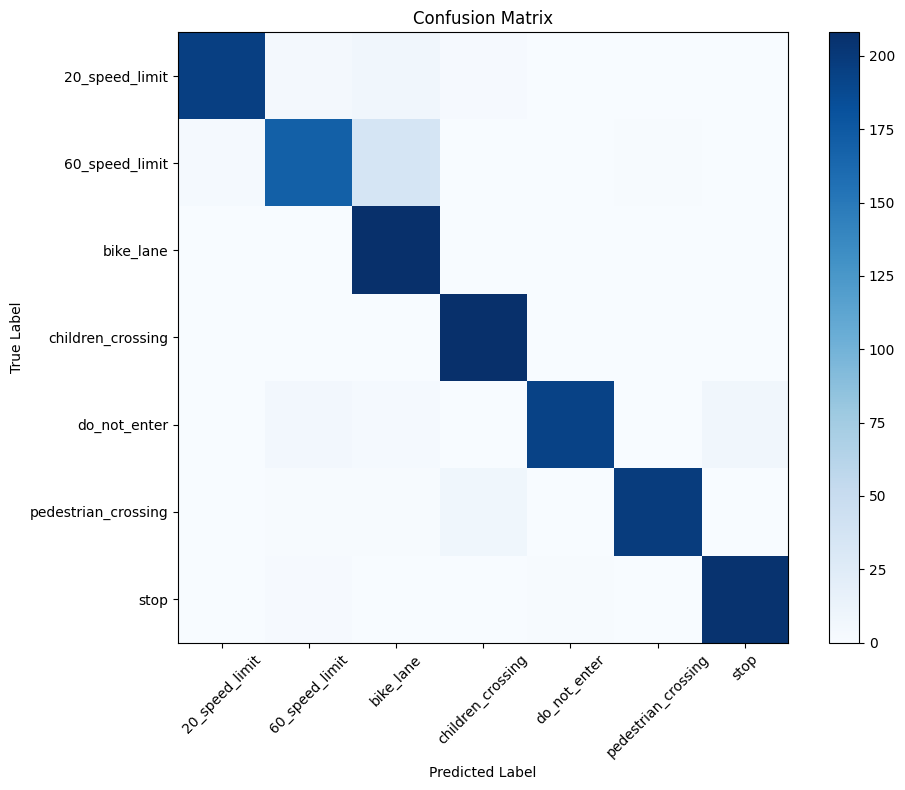

In [23]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(dataset.classes))
plt.xticks(tick_marks, dataset.classes, rotation=45)
plt.yticks(tick_marks, dataset.classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()